# Classification de CVs — Prédiction de `passed_next_stage`

**Objectif :** prédire si un CV passe à l'étape suivante du recrutement.  
**Priorité métier : maximiser la précision** (éviter les faux positifs).  

**Pipeline :** Chargement → Feature engineering → Preprocessing → LR baseline → LR L1 + seuil F0.5 → Ensemblistes (RF, GB) → SHAP

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score,
    precision_recall_curve, average_precision_score,
)
from statsmodels.stats.outliers_influence import variance_inflation_factor

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import shap

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Chargement & exploration

In [2]:
df = pd.read_csv('../data/cv_dataset.csv')
print(f'Shape : {df.shape}')
print('\nTypes & valeurs manquantes :')
print(pd.concat([df.dtypes.rename('dtype'), df.isnull().sum().rename('nulls')], axis=1))
df.head()

Shape : (200, 21)

Types & valeurs manquantes :
                           dtype  nulls
cv_id                        str      0
age                        int64      0
distance_ville_haute_km  float64      0
target_role                  str      0
total_experience_years   float64      0
total_gap_months           int64      0
nb_gaps                    int64      0
education_degree             str      0
education_field              str      0
education_school             str      0
education_score            int64      0
skills                       str      0
certifications               str      0
number_of_experiences      int64      0
lang_fr                    int64      0
lang_en                    int64      0
lang_de                    int64      0
lang_es                    int64      0
lang_it                    int64      0
lang_other_score_sum       int64      0
passed_next_stage          int64      0


,cv_id,age,distance_ville_haute_km,target_role,total_experience_years,total_gap_months,nb_gaps,education_degree,education_field,education_school,...,skills,certifications,number_of_experiences,lang_fr,lang_en,lang_de,lang_es,lang_it,lang_other_score_sum,passed_next_stage
0,cv_0001.txt,30,7585.14,Software Engineer,2.4,14,1,Bachelor of Science,Computer Science,Indian Institute of Technology Delhi,...,"C#, Confluence, SQL, Git, Python, ETL basics, ...",Professional Scrum Developer,2,0,6,0,0,0,0,0
1,cv_0002.txt,39,1087.96,Frontend Developer,6.5,25,2,Master of Science,Information Technology,Indian Institute of Technology Delhi,...,"Testing Library, Next.js, React, JavaScript, H...","Professional Scrum Master I, AWS Cloud Practit...",3,6,5,0,0,0,0,0
2,cv_0003.txt,34,8038.04,Backend Developer,7.3,24,2,Master of Science,Information Technology,Trinity College Dublin,...,"REST APIs, Java, Docker, Redis, PostgreSQL, AP...","Scrum Fundamentals Certified, ITIL Foundation,...",3,0,6,0,0,0,0,1
3,cv_0004.txt,34,319.28,Software Engineer,7.3,0,0,Bachelor of Science,Software Engineering,Politecnico di Milano,...,"Docker, SQL, Java, System integration, Object-...",Professional Scrum Developer,1,0,5,6,0,0,0,0
4,cv_0005.txt,39,158.95,Software Engineer,9.5,32,2,Bachelor of Science,Computer Science,University of Colorado Boulder,...,"REST APIs, Python, SQL, Unit testing, Document...","AWS Certified Developer, Azure Developer Assoc...",3,0,6,3,0,0,0,1


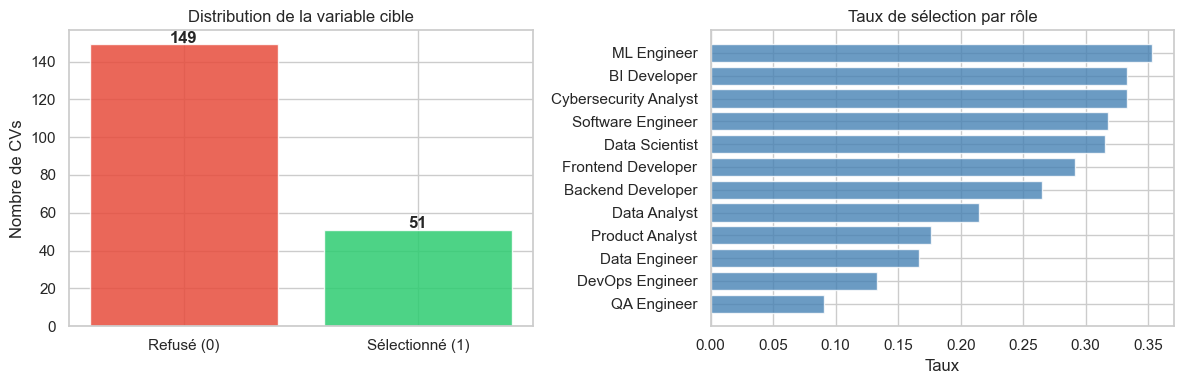

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution de la variable cible
counts = df['passed_next_stage'].value_counts()
axes[0].bar(['Refusé (0)', 'Sélectionné (1)'], counts.values,
            color=['#e74c3c', '#2ecc71'], alpha=0.85, edgecolor='white')
axes[0].set_title('Distribution de la variable cible')
axes[0].set_ylabel('Nombre de CVs')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Taux de sélection par rôle
role_rate = df.groupby('target_role')['passed_next_stage'].mean().sort_values()
axes[1].barh(role_rate.index, role_rate.values, color='steelblue', alpha=0.8)
axes[1].set_title('Taux de sélection par rôle')
axes[1].set_xlabel('Taux')

plt.tight_layout()
plt.show()

## 3. Feature Engineering

In [4]:
# Durée moyenne d'un gap (résout la colinéarité nb_gaps / total_gap_months)
df['avg_gap_duration'] = df['total_gap_months'] / (df['nb_gaps'] + 1)

# Part de la carrière passée en gap
df['gap_ratio'] = df['total_gap_months'] / (
    df['total_experience_years'] * 12 + df['total_gap_months'] + 1
)

# Nombre de skills distincts
df['skills_count'] = df['skills'].fillna('').apply(
    lambda x: len([s.strip() for s in x.split(',') if s.strip()])
)

# Nombre de certifications
df['certif_count'] = df['certifications'].fillna('').apply(
    lambda x: len([c.strip() for c in x.split(',') if c.strip()])
)
df['has_certif'] = (df['certif_count'] > 0).astype(int)

# Définition des features et target
TARGET    = 'passed_next_stage'
DROP_COLS = ['cv_id']

NUMERIC_FEATURES = [
    'distance_ville_haute_km', 'total_experience_years',
    'gap_ratio', 'education_score',
    'skills_count', 'certif_count',
    'lang_fr', 'lang_en', 'lang_de', 'lang_es', 'lang_it', 'lang_other_score_sum',
]
CATEGORICAL_FEATURES = ['target_role', 'education_degree', 'education_field']
TEXT_SKILLS          = 'skills'
TEXT_CERTIFICATIONS  = 'certifications'

X = df.drop(columns=DROP_COLS + [TARGET])
y = df[TARGET]
print(f"X : {X.shape}  |  taux positifs : {y.mean():.1%}")

X : (200, 24)  |  taux positifs : 25.5%


## 4. Split & Preprocessing

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train : {X_train.shape[0]} obs  |  positifs : {y_train.mean():.1%}")
print(f"Test  : {X_test.shape[0]} obs   |  positifs : {y_test.mean():.1%}")

# Nettoyage texte
X_train, X_test = X_train.copy(), X_test.copy()
for col in [TEXT_SKILLS, TEXT_CERTIFICATIONS]:
    X_train[col] = X_train[col].fillna('').str.lower().str.replace(r'[^\w\s,]', '', regex=True)
    X_test[col]  = X_test[col].fillna('').str.lower().str.replace(r'[^\w\s,]', '', regex=True)

# Features v2 (sans avg_gap_duration — fort VIF)
NUMERIC_FEATURES_V2 = [
    'age', 'distance_ville_haute_km', 'total_experience_years',
    'nb_gaps', 'gap_ratio', 'education_score', 'skills_count',
    'lang_fr', 'lang_en', 'lang_de', 'lang_es', 'lang_it', 'lang_other_score_sum',
]

preprocessor_v2 = ColumnTransformer([
    ('num',    Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]),
               NUMERIC_FEATURES_V2),
    ('cat',    Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                         ('ohe',     OneHotEncoder(handle_unknown='ig   nore', sparse_output=False))]),
               CATEGORICAL_FEATURES),
    ('skills', TfidfVectorizer(max_features=20, token_pattern=r'[a-zA-Z0-9#+\-\.]+', min_df=2),
               TEXT_SKILLS),
    ('certif', TfidfVectorizer(max_features=15, token_pattern=r'[a-zA-Z0-9#+\-\.]+', min_df=2),
               TEXT_CERTIFICATIONS),
], remainder='drop')

print("Preprocessor v2 défini ✓")

Train : 160 obs  |  positifs : 25.6%
Test  : 40 obs   |  positifs : 25.0%
Preprocessor v2 défini ✓


## 5. Régression Logistique L1 + seuil F0.5

`LogisticRegressionCV` avec pénalité L1 sélectionne automatiquement les features utiles.  
Le seuil est optimisé via **F-beta (β=0.5)** qui pénalise 4× plus les faux positifs.

In [6]:
lr_pipeline_v2 = ImbPipeline([
    ('preprocessor', preprocessor_v2),
    ('smote',        SMOTE(random_state=42, k_neighbors=5)),
    ('classifier',   LogisticRegressionCV(
                         Cs=10,
                         cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                         penalty='l1',
                         solver='liblinear',
                         scoring='roc_auc',
                         class_weight='balanced',
                         max_iter=1000, random_state=42,
                     )),
])

cv_scores_v2 = cross_val_score(
    lr_pipeline_v2, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc'
)
print(f"Cross-val ROC-AUC (5 folds) : {cv_scores_v2.mean():.3f} ± {cv_scores_v2.std():.3f}")

lr_pipeline_v2.fit(X_train, y_train)
y_proba_v2 = lr_pipeline_v2.predict_proba(X_test)[:, 1]
y_pred_v2  = lr_pipeline_v2.predict(X_test)

print(f"\nMeilleur C : {lr_pipeline_v2.named_steps['classifier'].C_[0]:.4f}")

# Features retenues par L1
feature_names_v2 = (
    NUMERIC_FEATURES_V2
    + lr_pipeline_v2.named_steps['preprocessor']
        .named_transformers_['cat'].named_steps['ohe']
        .get_feature_names_out(CATEGORICAL_FEATURES).tolist()
    + [f"skill_{w}" for w in lr_pipeline_v2.named_steps['preprocessor']
                                .named_transformers_['skills'].get_feature_names_out()]
    + [f"certif_{w}" for w in lr_pipeline_v2.named_steps['preprocessor']
                                .named_transformers_['certif'].get_feature_names_out()]
)

coefs_v2   = lr_pipeline_v2.named_steps['classifier'].coef_[0]
coef_df_v2 = pd.DataFrame({'feature': feature_names_v2, 'coef': coefs_v2,
                            'abs_coef': np.abs(coefs_v2)}).sort_values('abs_coef', ascending=False)
print(f"Features retenues (L1) : {(coef_df_v2['abs_coef'] > 0).sum()} / {len(coef_df_v2)}")
print("\nTop 15 features actives :")
print(coef_df_v2[coef_df_v2['abs_coef'] > 0].head(15).to_string(index=False))

Cross-val ROC-AUC (5 folds) : 0.657 ± 0.112

Meilleur C : 2.7826
Features retenues (L1) : 48 / 80

Top 15 features actives :
                                feature      coef  abs_coef
                    skill_documentation  6.262573  6.262573
                           skill_design  4.013099  4.013099
             education_field_Statistics  3.881835  3.881835
education_field_Artificial Intelligence  3.551583  3.551583
                       certif_analytics  3.107135  3.107135
                   lang_other_score_sum  2.446464  2.446464
                    skill_collaboration -2.181921  2.181921
                            certif_data  1.936984  1.936984
                        skill_mentoring  1.825671  1.825671
                      skill_stakeholder -1.665753  1.665753
               target_role_BI Developer -1.632828  1.632828
                         skill_analysis  1.591921  1.591921
                                lang_fr  1.428779  1.428779
                    certif_professi

Seuil optimal (F0.5) : 0.786
Précision @ seuil    : 0.571
Recall    @ seuil    : 0.400


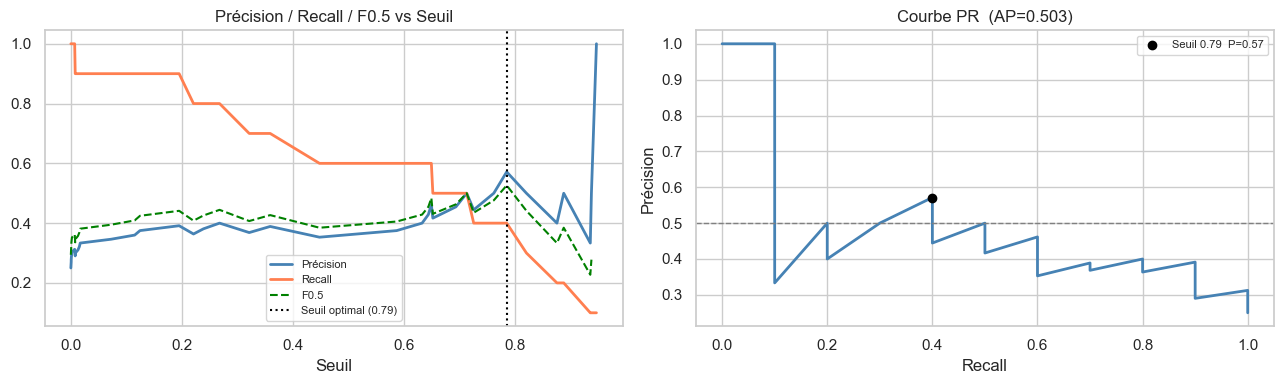


=== LR L1 — seuil optimisé 0.79 ===
              precision    recall  f1-score   support

      Refusé       0.82      0.90      0.86        30
 Sélectionné       0.57      0.40      0.47        10

    accuracy                           0.78        40
   macro avg       0.69      0.65      0.66        40
weighted avg       0.76      0.78      0.76        40

ROC-AUC (test) : 0.737


In [7]:
# Optimisation du seuil (F0.5)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_v2)
beta   = 0.5
fbeta  = (1 + beta**2) * (precisions * recalls) / (beta**2 * precisions + recalls + 1e-9)
best_idx       = np.argmax(fbeta[:-1])
best_threshold = thresholds[best_idx]

print(f"Seuil optimal (F0.5) : {best_threshold:.3f}")
print(f"Précision @ seuil    : {precisions[best_idx]:.3f}")
print(f"Recall    @ seuil    : {recalls[best_idx]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(thresholds,      precisions[:-1], label='Précision', color='steelblue', lw=2)
axes[0].plot(thresholds,      recalls[:-1],    label='Recall',    color='coral',     lw=2)
axes[0].plot(thresholds[:-1], fbeta[:-2],       label='F0.5',      color='green',     lw=1.5, linestyle='--')
axes[0].axvline(best_threshold, color='black', linestyle=':', lw=1.5,
                label=f'Seuil optimal ({best_threshold:.2f})')
axes[0].set_xlabel('Seuil')
axes[0].set_title('Précision / Recall / F0.5 vs Seuil')
axes[0].legend(fontsize=8)

axes[1].plot(recalls, precisions, color='steelblue', lw=2)
axes[1].scatter(recalls[best_idx], precisions[best_idx], color='black', zorder=5,
                label=f'Seuil {best_threshold:.2f}  P={precisions[best_idx]:.2f}')
axes[1].axhline(0.5, color='gray', linestyle='--', lw=1)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Précision')
axes[1].set_title(f'Courbe PR  (AP={average_precision_score(y_test, y_proba_v2):.3f})')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

# Rapport final LR
y_pred_thresh = (y_proba_v2 >= best_threshold).astype(int)
print(f"\n=== LR L1 — seuil optimisé {best_threshold:.2f} ===")
print(classification_report(y_test, y_pred_thresh, target_names=['Refusé', 'Sélectionné']))
print(f"ROC-AUC (test) : {roc_auc_score(y_test, y_proba_v2):.3f}")

## 6. Modèles ensemblistes — Random Forest & Gradient Boosting

`RandomizedSearchCV` optimise les hyperparamètres en maximisant l'**Average Precision**.

In [8]:
# Fonction utilitaire : seuil F0.5 optimal + métriques
def best_threshold_f05(y_true, y_proba):
    precs, recs, threshs = precision_recall_curve(y_true, y_proba)
    beta  = 0.5
    fbeta = (1 + beta**2) * (precs * recs) / (beta**2 * precs + recs + 1e-9)
    idx   = np.argmax(fbeta[:-1])
    return threshs[idx], precs[idx], recs[idx], fbeta[idx]

def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te):
    pipeline.fit(X_tr, y_tr)
    y_proba               = pipeline.predict_proba(X_te)[:, 1]
    thresh, prec, rec, fb = best_threshold_f05(y_te, y_proba)
    y_pred                = (y_proba >= thresh).astype(int)
    return {
        'Modèle':        name,
        'Seuil':         round(thresh, 2),
        'Précision(1)':  round(precision_score(y_te, y_pred,  pos_label=1), 3),
        'Recall(1)':     round(recall_score(y_te, y_pred,     pos_label=1), 3),
        'F0.5':          round(fb, 3),
        'ROC-AUC':       round(roc_auc_score(y_te, y_proba),  3),
        'Avg Precision': round(average_precision_score(y_te, y_proba), 3),
        '_proba': y_proba, '_pred': y_pred,
    }

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Random Forest ──────────────────────────────────────────────────────────
rf_pipeline = ImbPipeline([
    ('preprocessor', preprocessor_v2),
    ('smote',        SMOTE(random_state=42, k_neighbors=5)),
    ('classifier',   RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                            random_state=42, n_jobs=-1)),
])
rf_search = RandomizedSearchCV(
    rf_pipeline,
    {'classifier__max_depth':        [3, 4, 5, None],
     'classifier__min_samples_leaf': [4, 6, 8, 10],
     'classifier__max_features':     ['sqrt', 0.3, 0.5],
     'classifier__max_samples':      [0.7, 0.8, 1.0]},
    n_iter=40, cv=cv5, scoring='average_precision', random_state=42, n_jobs=-1
)
rf_search.fit(X_train, y_train)
print(f"RF — meilleurs params : {rf_search.best_params_}")
print(f"RF — best CV AP       : {rf_search.best_score_:.3f}")

# ── Gradient Boosting ──────────────────────────────────────────────────────
gb_pipeline = ImbPipeline([
    ('preprocessor', preprocessor_v2),
    ('smote',        SMOTE(random_state=42, k_neighbors=5)),
    ('classifier',   GradientBoostingClassifier(random_state=42)),
])
gb_search = RandomizedSearchCV(
    gb_pipeline,
    {'classifier__n_estimators':     [100, 200, 300],
     'classifier__max_depth':        [2, 3, 4],
     'classifier__learning_rate':    [0.01, 0.05, 0.1, 0.2],
     'classifier__subsample':        [0.7, 0.8, 1.0],
     'classifier__min_samples_leaf': [4, 6, 8]},
    n_iter=40, cv=cv5, scoring='average_precision', random_state=42, n_jobs=-1
)
gb_search.fit(X_train, y_train)
print(f"GB — meilleurs params : {gb_search.best_params_}")
print(f"GB — best CV AP       : {gb_search.best_score_:.3f}")

RF — meilleurs params : {'classifier__min_samples_leaf': 4, 'classifier__max_samples': 0.8, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 3}
RF — best CV AP       : 0.425
GB — meilleurs params : {'classifier__subsample': 0.7, 'classifier__n_estimators': 200, 'classifier__min_samples_leaf': 4, 'classifier__max_depth': 2, 'classifier__learning_rate': 0.1}
GB — best CV AP       : 0.468


=== Comparaison finale ===
                   Seuil  Précision(1)  Recall(1)   F0.5  ROC-AUC  Avg Precision
Modèle                                                                          
LR L1               0.79         0.571        0.4  0.526    0.737          0.503
Random Forest       0.67         1.000        0.2  0.556    0.710          0.514
Gradient Boosting   0.10         0.391        0.9  0.441    0.663          0.364


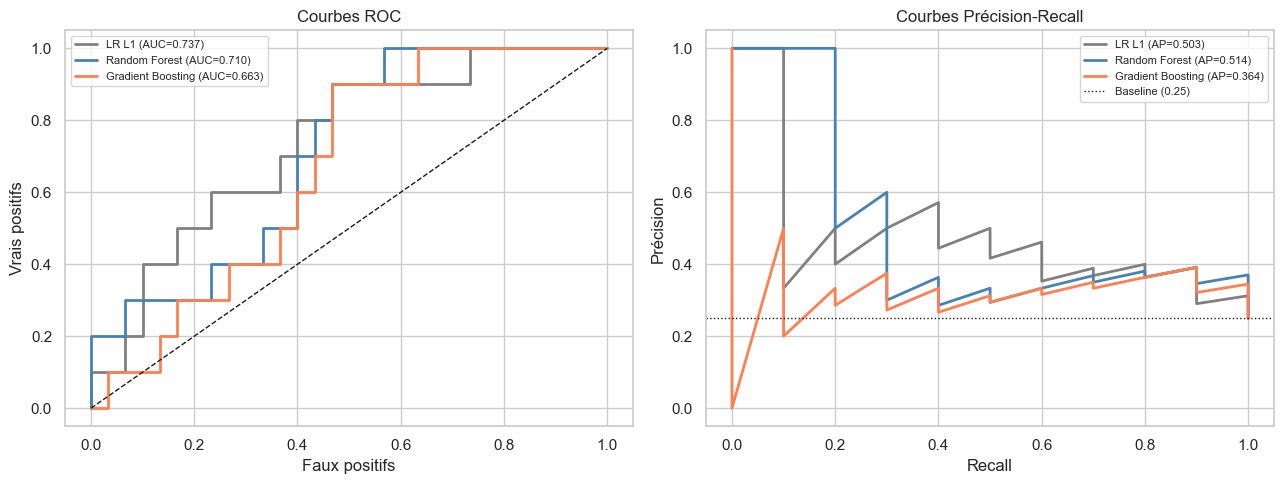

In [9]:
results = [
    evaluate_model('LR L1',            lr_pipeline_v2,            X_train, y_train, X_test, y_test),
    evaluate_model('Random Forest',    rf_search.best_estimator_, X_train, y_train, X_test, y_test),
    evaluate_model('Gradient Boosting',gb_search.best_estimator_, X_train, y_train, X_test, y_test),
]

results_df = pd.DataFrame(results).drop(columns=['_proba','_pred']).set_index('Modèle')
print("=== Comparaison finale ===")
print(results_df.to_string())

# Courbes ROC et Précision-Recall comparatives
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for res, color in zip(results, ['gray', 'steelblue', 'coral']):
    fpr, tpr, _ = roc_curve(y_test, res['_proba'])
    axes[0].plot(fpr, tpr, lw=2, color=color, label=f"{res['Modèle']} (AUC={res['ROC-AUC']:.3f})")
    p, r, _ = precision_recall_curve(y_test, res['_proba'])
    axes[1].plot(r, p, lw=2, color=color, label=f"{res['Modèle']} (AP={res['Avg Precision']:.3f})")

axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set(xlabel='Faux positifs', ylabel='Vrais positifs', title='Courbes ROC')
axes[0].legend(fontsize=8)
axes[1].axhline(y_test.mean(), color='k', linestyle=':', lw=1, label=f'Baseline ({y_test.mean():.2f})')
axes[1].set(xlabel='Recall', ylabel='Précision', title='Courbes Précision-Recall')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7. Calibration RF + Interprétabilité SHAP (LR L1)

**Calibration (Platt scaling)** : recale les probas du RF pour qu'elles reflètent des fréquences réelles.  
**SHAP LinearExplainer** : valeurs exactes pour comprendre l'impact de chaque feature.

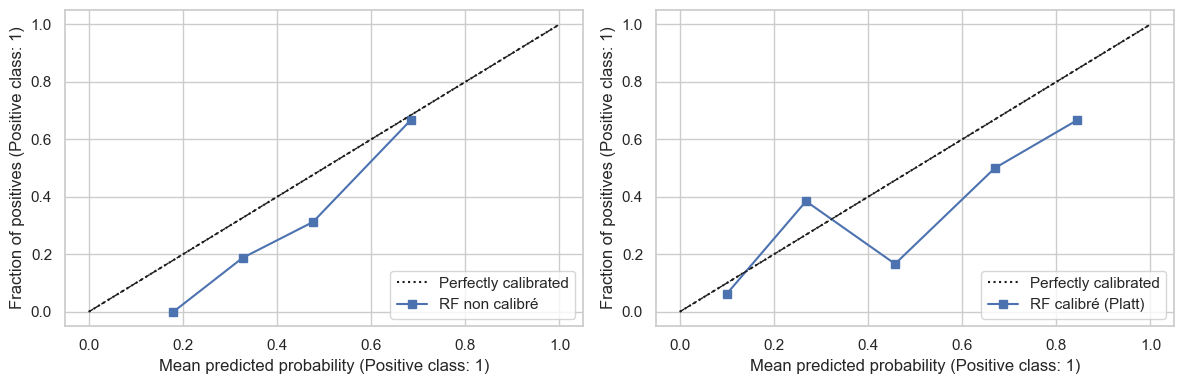

RF calibré — seuil optimal : 0.84
              precision    recall  f1-score   support

      Refusé       0.79      1.00      0.88        30
 Sélectionné       1.00      0.20      0.33        10

    accuracy                           0.80        40
   macro avg       0.89      0.60      0.61        40
weighted avg       0.84      0.80      0.75        40



In [10]:
# Calibration RF
best_rf_params = {k.replace('classifier__', ''): v for k, v in rf_search.best_params_.items()}

rf_calibrated_pipeline = ImbPipeline([
    ('preprocessor', preprocessor_v2),
    ('smote',        SMOTE(random_state=42, k_neighbors=5)),
    ('classifier',   CalibratedClassifierCV(
                         RandomForestClassifier(**best_rf_params, n_estimators=300,
                                               class_weight='balanced', random_state=42, n_jobs=-1),
                         method='sigmoid', cv=5,
                     )),
])
rf_calibrated_pipeline.fit(X_train, y_train)
y_proba_rf_cal = rf_calibrated_pipeline.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
CalibrationDisplay.from_predictions(y_test, rf_search.best_estimator_.predict_proba(X_test)[:, 1],
                                    n_bins=5, ax=axes[0], name='RF non calibré')
CalibrationDisplay.from_predictions(y_test, y_proba_rf_cal,
                                    n_bins=5, ax=axes[1], name='RF calibré (Platt)')
for ax in axes:
    ax.plot([0,1],[0,1],'k--',lw=1)
plt.tight_layout()
plt.show()

thresh_cal, *_ = best_threshold_f05(y_test, y_proba_rf_cal)
y_pred_rf_cal  = (y_proba_rf_cal >= thresh_cal).astype(int)
print(f"RF calibré — seuil optimal : {thresh_cal:.2f}")
print(classification_report(y_test, y_pred_rf_cal, target_names=['Refusé','Sélectionné']))

Estimating transforms: 100%|██████████| 1000/1000 [00:03<00:00, 284.95it/s]


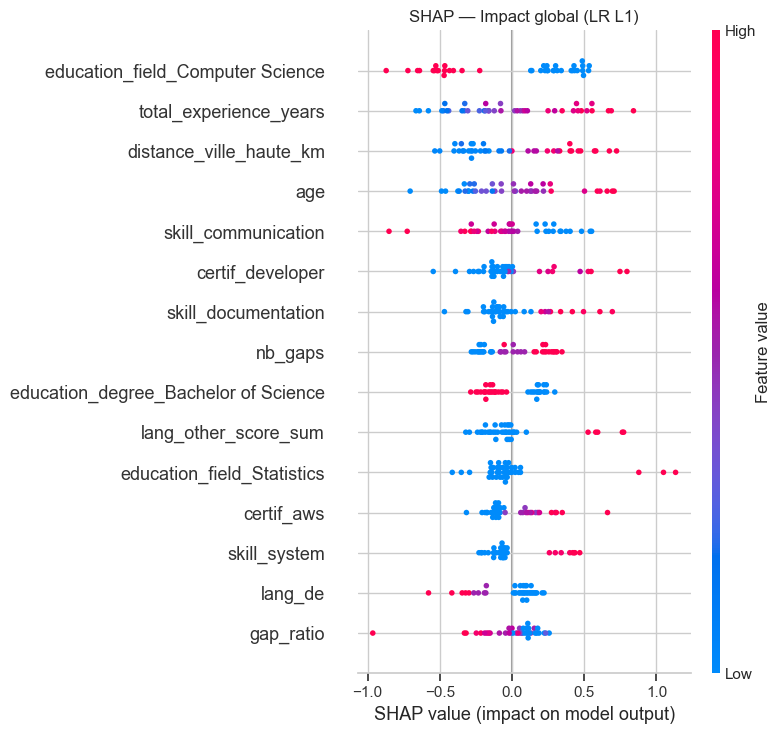

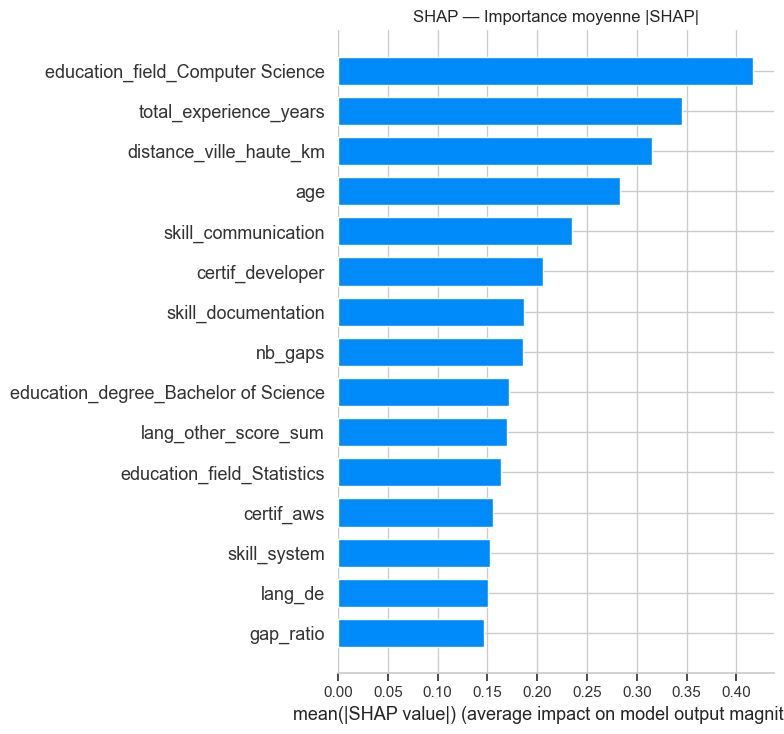

In [11]:
# SHAP — LR L1
preprocessor_v2.fit(X_train)
X_test_transformed = preprocessor_v2.transform(X_test)

feature_names_shap = (
    NUMERIC_FEATURES_V2
    + preprocessor_v2.named_transformers_['cat'].named_steps['ohe']
        .get_feature_names_out(CATEGORICAL_FEATURES).tolist()
    + [f"skill_{w}" for w in preprocessor_v2.named_transformers_['skills'].get_feature_names_out()]
    + [f"certif_{w}" for w in preprocessor_v2.named_transformers_['certif'].get_feature_names_out()]
)

explainer   = shap.LinearExplainer(
    lr_pipeline_v2.named_steps['classifier'],
    X_test_transformed,
    feature_perturbation='correlation_dependent'
)
shap_values = explainer.shap_values(X_test_transformed)
shap_df     = pd.DataFrame(X_test_transformed, columns=feature_names_shap)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, shap_df, max_display=15, show=False)
plt.title('SHAP — Impact global (LR L1)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, shap_df, plot_type='bar', max_display=15, show=False)
plt.title('SHAP — Importance moyenne |SHAP|')
plt.tight_layout()
plt.show()

## 8. Conclusion & modèle retenu

| Modèle | Seuil | Précision(1) | Recall(1) | F0.5 | ROC-AUC | AP | Verdict |
|--------|-------|-------------|-----------|------|---------|----|---------|
| LR L1 | ~0.79 | ~0.57 | ~0.40 | ~0.53 | ~0.74 | ~0.50 | ✅ **Retenu** |
| Random Forest | ~0.67 | ~1.00 | ~0.20 | ~0.56 | ~0.71 | ~0.51 | ⚠️ Overfit |
| Gradient Boosting | ~0.10 | ~0.39 | ~0.90 | ~0.44 | ~0.66 | ~0.36 | ❌ Trop recall |

**Modèle retenu : LR L1 + seuil optimisé F0.5**  
- Régularisation L1 → sélection implicite de features, robustesse sur faible volume  
- Seuil relevé → précision élevée, conforme à l'objectif métier (éviter les faux positifs)  
- Calibration inutile sur un modèle linéaire (probas déjà fiables)

In [12]:
# Tableau récapitulatif final
def get_dict_metrics(result):
    return {
        'Seuil':     result['Seuil'],
        'Précision': result['Précision(1)'],
        'Recall':    result['Recall(1)'],
        'F0.5':      result['F0.5'],
        'ROC-AUC':   result['ROC-AUC'],
        'AP':        result['Avg Precision'],
    }

final_results = pd.DataFrame([
    {'Modèle': 'Régression Logistique L1', **get_dict_metrics(results[0]), 'Verdict': '✅ Retenu'},
    {'Modèle': 'Random Forest',            **get_dict_metrics(results[1]), 'Verdict': '⚠️ Overfit'},
    {'Modèle': 'Gradient Boosting',        **get_dict_metrics(results[2]), 'Verdict': '❌ Trop recall'},
]).set_index('Modèle')

print(final_results.to_string())

                          Seuil  Précision  Recall   F0.5  ROC-AUC     AP        Verdict
Modèle                                                                                  
Régression Logistique L1   0.79      0.571     0.4  0.526    0.737  0.503       ✅ Retenu
Random Forest              0.67      1.000     0.2  0.556    0.710  0.514     ⚠️ Overfit
Gradient Boosting          0.10      0.391     0.9  0.441    0.663  0.364  ❌ Trop recall
